In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [6]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/dr9/dr9.0/temp/sweep-170p020-180p025.fits'))
print(len(cat))

ex_columns = ['BX', 'BY']
cat1 = Table(fitsio.read('/Users/rongpu/Documents/Data/dr9/dr9.0/temp/sweep-170p020-180p025-ex.fits', columns=ex_columns))
cat = hstack([cat, cat1])

3703959


In [7]:
maskbits = [1, 8, 9, 12, 13]
min_nobs = 2

cat_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    cat_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~cat_clean)/len(cat_clean))

cat_clean &= (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
print(np.sum(~cat_clean)/len(cat_clean))

cat = cat[cat_clean]
print(len(cat))

0.014283365447619696
0.031062708847479144
3588904


In [8]:
maskbits = np.arange(14)
min_nobs = 2

cat_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    cat_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~cat_clean)/len(cat_clean))

cat_clean &= (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
print(np.sum(~cat_clean)/len(cat_clean))

cat = cat[cat_clean]
print(len(cat))

0.01707317888692481
0.01707317888692481
3527630


In [9]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    gmag = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    rmag = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    zmag = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    w1mag = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    w2mag = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    rfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']/cat['MW_TRANSMISSION_R'])
    zfibermag = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'])
    zfibertotmag = 22.5 - 2.5*np.log10(cat['FIBERTOTFLUX_Z']/cat['MW_TRANSMISSION_Z'])

    gmag[~np.isfinite(gmag)] = 100.
    rmag[~np.isfinite(rmag)] = 100.
    zmag[~np.isfinite(zmag)] = 100.
    w1mag[~np.isfinite(w1mag)] = 100.
    w2mag[~np.isfinite(w2mag)] = 100.
    rfibermag[~np.isfinite(rfibermag)] = 100.
    zfibermag[~np.isfinite(zfibermag)] = 100.
    zfibertotmag[~np.isfinite(zfibertotmag)] = 100.
    
    gflux_ivar = cat['FLUX_IVAR_R']
    
    gaia_g = cat['GAIA_PHOT_G_MEAN_MAG']
    
cat.add_columns([gmag, rmag, zmag, w1mag, w2mag, zfibermag, rfibermag], names=['gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'zfibermag', 'rfibermag'])

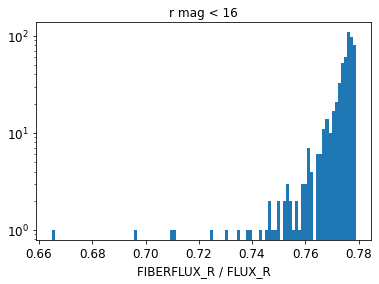

In [10]:
mask = (cat['TYPE']=='PSF') & (rmag<16) & (cat['FLUX_R']>0)
plt.hist((cat['FIBERFLUX_R'][mask]/cat['FLUX_R'][mask]), 100, log=True)
plt.xlabel('FIBERFLUX_R / FLUX_R')
plt.title('r mag < 16')
plt.show()

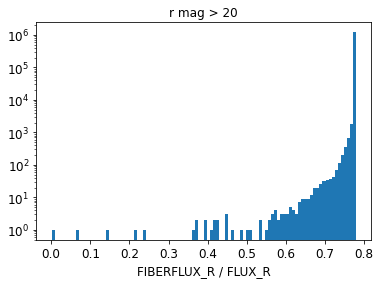

In [11]:
mask = (cat['TYPE']=='PSF') & (rmag>20) & (cat['FLUX_R']>0)
plt.hist((cat['FIBERFLUX_R'][mask]/cat['FLUX_R'][mask]), 100, log=True)
plt.xlabel('FIBERFLUX_R / FLUX_R')
plt.title('r mag > 20')
plt.show()

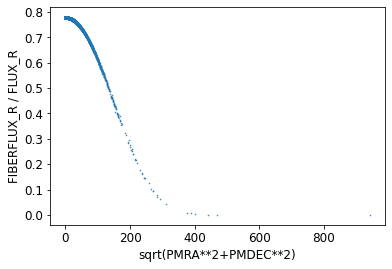

In [27]:
mask = (cat['TYPE']=='PSF') & (cat['FLUX_R']>0)
plt.plot(np.sqrt(cat['PMRA']**2+cat['PMDEC']**2)[mask], (cat['FIBERFLUX_R'][mask]/cat['FLUX_R'][mask]), '.', ms=1)
plt.xlabel('sqrt(PMRA**2+PMDEC**2)')
plt.ylabel('FIBERFLUX_R / FLUX_R')
plt.show()

--------

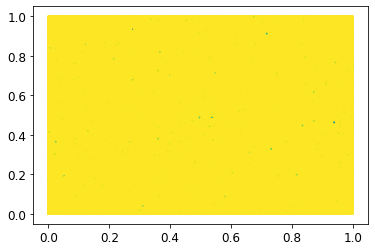

In [18]:
mask = (cat['TYPE']=='PSF') & (cat['FLUX_R']>0)
plt.scatter(np.fmod(cat['BX'], 1.)[mask], np.fmod(cat['BY'], 1.)[mask], c=(cat['FIBERFLUX_R'][mask]/cat['FLUX_R'][mask]), s=1)
plt.show()

In [15]:
# maskbits = np.arange(14)
# min_nobs = 2

# cat_clean = np.ones(len(cat), dtype=bool)
# for bit in maskbits:
#     cat_clean &= (cat['MASKBITS'] & 2**bit)==0
# print(np.sum(~cat_clean)/len(cat_clean))

# cat_clean &= (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
# print(np.sum(~cat_clean)/len(cat_clean))

# cat = cat[cat_clean]
# print(len(cat))

0.77839774


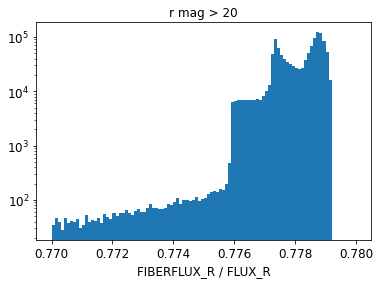

In [14]:
mask = (cat['TYPE']=='PSF') & (rmag>20) & (cat['FLUX_R']>0)
print(np.median((cat['FIBERFLUX_R'][mask]/cat['FLUX_R'][mask])))
plt.hist((cat['FIBERFLUX_R'][mask]/cat['FLUX_R'][mask]), 100, range=(0.77, 0.78), log=True)
plt.xlabel('FIBERFLUX_R / FLUX_R')
plt.title('r mag > 20')
plt.show()

0.77839774


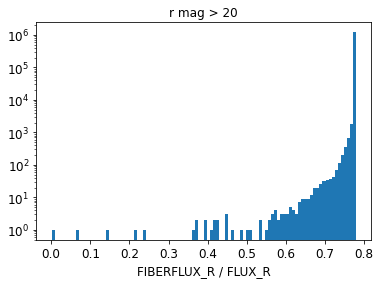

In [48]:
mask = (cat['TYPE']=='PSF') & (rmag>20) & (cat['FLUX_R']>0)
print(np.median((cat['FIBERFLUX_R'][mask]/cat['FLUX_R'][mask])))
plt.hist((cat['FIBERFLUX_R'][mask]/cat['FLUX_R'][mask]), 100, log=True)
plt.xlabel('FIBERFLUX_R / FLUX_R')
plt.title('r mag > 20')
plt.show()

0.77839774


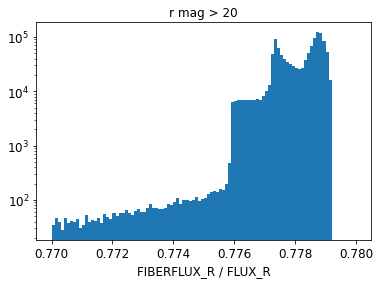

In [50]:
mask = (cat['TYPE']=='PSF') & (rmag>20) & (cat['FLUX_R']>0)
print(np.median((cat['FIBERFLUX_R'][mask]/cat['FLUX_R'][mask])))
plt.hist((cat['FIBERFLUX_R'][mask]/cat['FLUX_R'][mask]), 100, range=(0.77, 0.78), log=True)
plt.xlabel('FIBERFLUX_R / FLUX_R')
plt.title('r mag > 20')
plt.show()

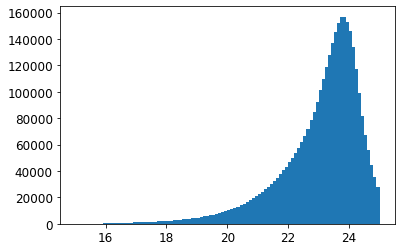

In [24]:
plt.hist(rmag, 100, range=(15, 25));

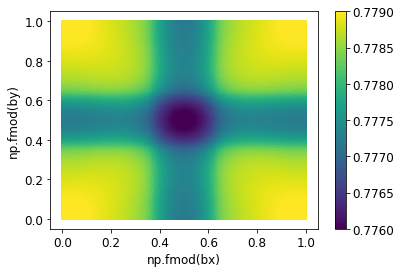

In [25]:
mask = (cat['TYPE']=='PSF') & (rmag>22) & (cat['FLUX_R']>0)
plt.scatter(np.fmod(cat['BX'], 1.)[mask], np.fmod(cat['BY'], 1.)[mask], c=(cat['FIBERFLUX_R'][mask]/cat['FLUX_R'][mask]), s=1, vmin=0.776, vmax=0.779)
plt.xlabel('np.fmod(bx)')
plt.ylabel('np.fmod(by)')
plt.colorbar()
plt.show()